In [53]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as snb
import os 
import seaborn as sns
from scipy import stats
from itertools import combinations
from scipy.stats import bootstrap
data_filepath = "../data/interventions/"

In [73]:
data_intervention_A_df = pd.read_csv(data_filepath+'data_A=-2.csv').drop(columns=["Unnamed: 0"])
data_intervention_B_df = pd.read_csv(data_filepath+'data_B=-2.csv').drop(columns=["Unnamed: 0"])
data_intervention_C_df = pd.read_csv(data_filepath+'data_C=-2.csv').drop(columns=["Unnamed: 0"])
data_intervention_D_df = pd.read_csv(data_filepath+'data_D=-2.csv').drop(columns=["Unnamed: 0"])
data_intervention_E_df = pd.read_csv(data_filepath+'data_E=2.csv').drop(columns=["Unnamed: 0"])
data_intervention_F_df = pd.read_csv(data_filepath+'data_F=-2.csv').drop(columns=["Unnamed: 0"])
data = pd.read_csv(data_filepath+'data.csv').drop(columns=["Unnamed: 0"])
datasets = {
    "data": data,
    "intervention_A": data_intervention_A_df,
    "intervention_B": data_intervention_B_df,
    "intervention_C": data_intervention_C_df,
    "intervention_D": data_intervention_D_df,
    "intervention_E": data_intervention_E_df,
    "intervention_F": data_intervention_F_df,
}

data_var = ["A", "B", "C", "D", "E","F"]

In [63]:
rng = np.random.default_rng(42)

bootstrap_results = {}

for name, df in datasets.items():         
    bootstrap_results[name] = {}
    for var in data_var:
        data = (df[var].values,)       
        res = bootstrap(
            data,
            np.std,
            confidence_level=0.90,
            n_resamples=200,
            random_state=rng
        )
      

        bootstrap_results[name][var] = res.bootstrap_distribution

print(len(bootstrap_results["data"]["A"]))

200


/opt/homebrew/Caskroom/miniconda/base/lib/python3.11/site-packages/scipy/stats/_resampling.py:149: RuntimeWarning: invalid value encountered in scalar divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
/var/folders/vg/vh2t_3295rlgtkq4vw_kd8s40000gn/T/ipykernel_50751/3647884920.py:9: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  res = bootstrap(


In [72]:
def significant_difference(datasets: dict) -> pd.DataFrame:
    
    results = []
    
    for (name1, data_1), (name2, data_2) in combinations(datasets.items(), 2):
        for var in data_var:
            ks_result = stats.kstest(data_1[var], data_2[var])
            p_value = ks_result.pvalue
            results.append({
                "Dataset 1": name1,
                "Dataset 2": name2,
                "Variable": var,
                "KS Statistic": round(ks_result.statistic, 4),
                "P-Value": round(p_value, 4),
                "Identical Distribution": p_value >= 0.1,
                "mean-difference": np.abs(np.mean(data_1[var]) - np.mean(data_2[var])),
                "relative-mean-difference": (np.abs(np.mean(data_1[var]) - np.mean(data_2[var]))/(np.mean(data_1[var]))),
                "std-difference": np.abs(np.std(data_1[var]) - np.std(data_2[var]))
            })
    
    return pd.DataFrame(results)




results_df = significant_difference(datasets)
results_df

,Dataset 1,Dataset 2,Variable,KS Statistic,P-Value,Identical Distribution,mean-difference,relative-mean-difference,std-difference
0,data,intervention_A,A,1.00,0.0000,False,10.738074,1.228883,18.703372
1,data,intervention_A,B,0.18,0.0782,False,1.180929,0.391080,0.485534
2,data,intervention_A,C,0.16,0.1548,True,0.236134,4.838401,0.165871
3,data,intervention_A,D,0.09,0.8154,True,0.393297,-0.311951,0.498919
4,data,intervention_A,E,0.07,0.9684,True,0.034736,-0.032040,0.084555
5,data,intervention_A,F,0.09,0.8154,True,0.173499,0.151474,0.054379
6,data,intervention_C,A,0.10,0.8846,True,0.425167,0.048657,1.939692
7,data,intervention_C,B,0.22,0.0753,False,1.180399,0.390904,1.031061
8,data,intervention_C,C,0.95,0.0000,False,2.048804,41.980139,1.207289
9,data,intervention_C,D,0.14,0.5185,True,0.252276,-0.200098,0.200290


In [27]:
# Step 3+4: Run all pairwise KS tests and build edge candidates
intervention_datasets = {
    "A": data_intervention_A_df,
    "B": data_intervention_B_df,
    "C": data_intervention_C_df,
    "D": data_intervention_D_df,
    # _H intentionally omitted — unobserved in practice
}

observed_vars = ["A", "B", "C", "D"]
results = []

for intervened_var, int_df in intervention_datasets.items():
    for var in observed_vars:
        if var == intervened_var:
            continue  # skip self-comparison
        ks = stats.kstest(data[var], int_df[var])
        results.append({
            "Intervened on": intervened_var,
            "Observed var": var,
            "KS statistic": round(ks.statistic, 4),
            "p-value": round(ks.pvalue, 4),
            "Distribution changed": ks.pvalue < 0.05
        })

ks_df = pd.DataFrame(results)

# Step 5: Print your guess
guess = [('A','B'), ('_H','A'), ('_H','D'), ('B','C'), ('C','D')]
print("Guess:", guess)
print("\nKS test summary:")
print(ks_df[ks_df["Distribution changed"]])

Guess: [('A', 'B'), ('_H', 'A'), ('_H', 'D'), ('B', 'C'), ('C', 'D')]

KS test summary:
  Intervened on Observed var  KS statistic  p-value  Distribution changed
2             A            D          0.36      0.0                  True


In [20]:
significant_difference(data, data_intervention_A_df)


A distribution of data 1 could be identical to the var in data 2 


B distribution of data 1 could be identical to the var in data 2 


C distribution of data 1 could be identical to the var in data 2 


D distribution of data 1 could be identical to the var in data 2 




In [8]:
graphs = [data, data_intervention_A_df, data_intervention_B_df, data_intervention_C_df,data_intervention_D_df, data_intervention_H_df]
names = ["None", "A","B", "C", "D", "H"]
for i ,d in enumerate(graphs):
    print("\n\n graph number:", i, " with intervention on: ", names[i])
    print(d.describe())



 graph number: 0  with intervention on:  None
                A           B           C           D
count  100.000000  100.000000  100.000000  100.000000
mean     0.896296    0.191583    0.178579    1.434714
std      1.878905    0.645093    1.186368    2.142663
min     -6.717589   -0.841172   -2.431978   -7.868835
25%      0.014862   -0.358031   -0.521310    0.499309
50%      0.943936   -0.018822    0.298307    1.442208
75%      2.032883    0.744403    0.783882    2.747948
max      6.501975    1.610015    4.131646    6.567001


 graph number: 1  with intervention on:  A
           A           B           C           D
count  100.0  100.000000  100.000000  100.000000
mean     0.0    0.162365    0.343183    0.587635
std      0.0    0.542491    1.237603    0.945948
min      0.0   -0.797836   -2.464638   -1.522425
25%      0.0   -0.234011   -0.527316    0.011620
50%      0.0    0.030241    0.351660    0.493361
75%      0.0    0.622319    1.240772    1.315127
max      0.0    1.522425    4

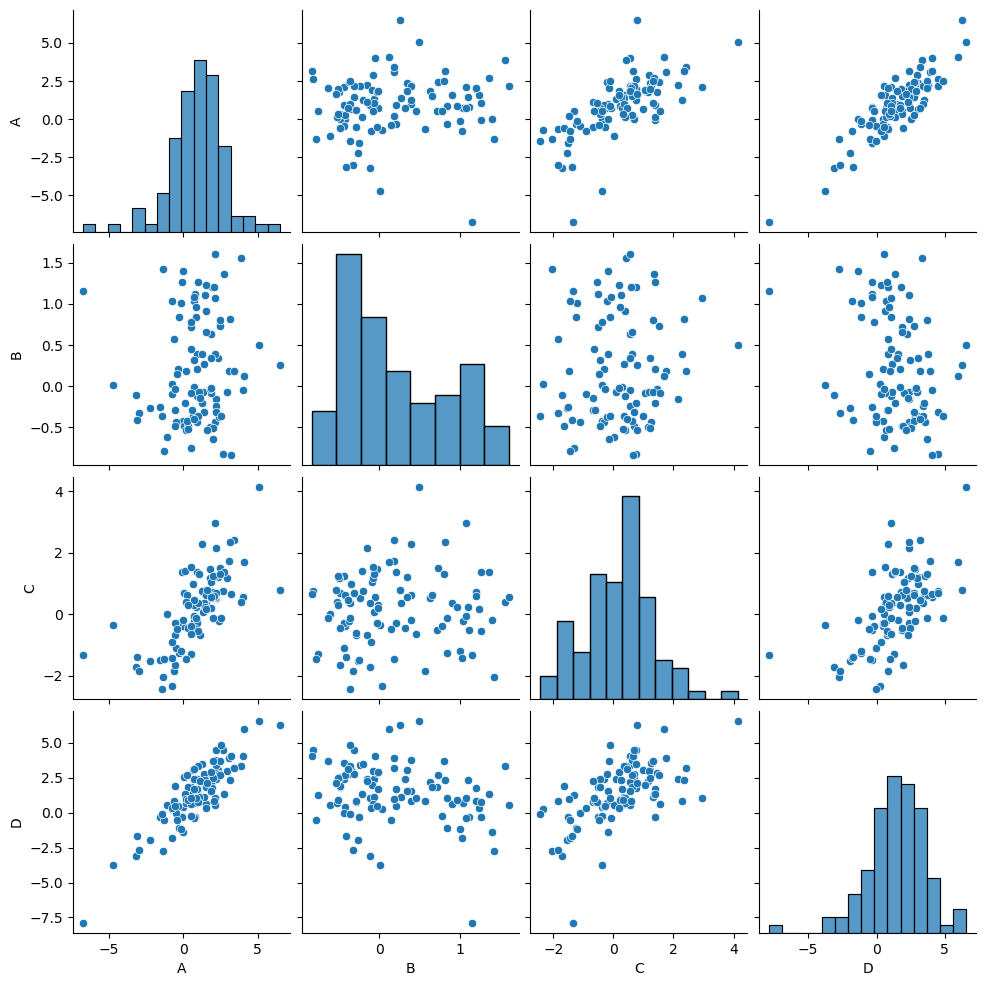

In [ ]:
sns.pairplot(data=data)


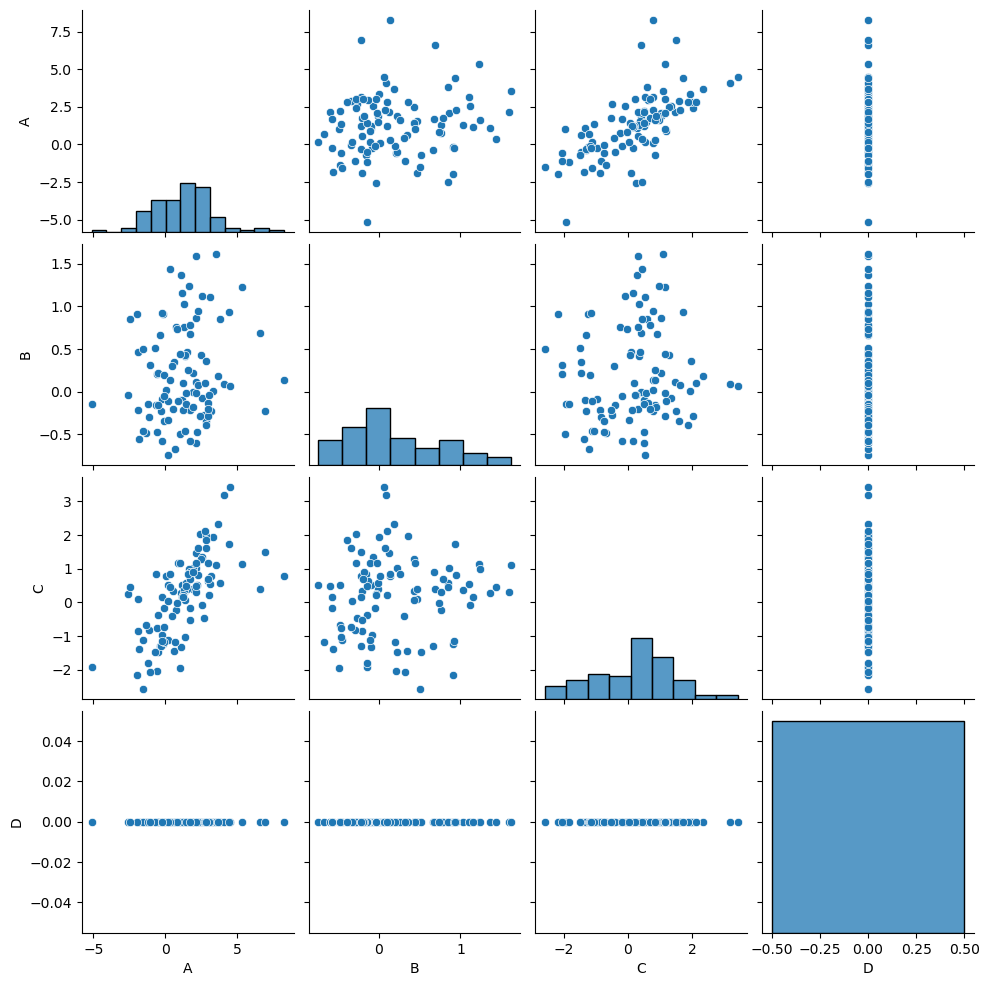

In [21]:
sns.pairplot(data=data_intervention_D_df)